<a href="https://colab.research.google.com/github/VitorXavier27/Trabalho-Final-IA/blob/main/TrabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install kagglehub -q

import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from zoneinfo import ZoneInfo

In [10]:
# Parâmetros de treinamento
TOTAL_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# Download e preparação dos dados
dataset_path = kagglehub.dataset_download("dariobaumberger/combined-kaggle-mushrooms-dataset")
images_dir = f"{dataset_path}/images" if os.path.exists(f"{dataset_path}/images") else dataset_path

image_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# Carregando o dataset base
complete_data = datasets.ImageFolder(images_dir, transform=image_transforms)

# Extraindo apenas 2% do total de dados
used_samples = int(0.02 * len(complete_data))
ignored_samples = len(complete_data) - used_samples
active_subset, _ = random_split(complete_data, [used_samples, ignored_samples])

# Dividindo entre treino (70%) e validação/teste (30%)
training_count = int(0.7 * len(active_subset))
testing_count = len(active_subset) - training_count
train_data, test_data = random_split(active_subset, [training_count, testing_count])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

total_categories = len(complete_data.classes)

print(f"Categorias identificadas: {total_categories}")
print(f" -> Imagens de Treino: {len(train_data)}")
print(f" -> Imagens de Teste: {len(test_data)} (Amostra de 2%)")

Using Colab cache for faster access to the 'combined-kaggle-mushrooms-dataset' dataset.
Categorias identificadas: 555
 -> Imagens de Treino: 2735
 -> Imagens de Teste: 1173 (Amostra de 2%)


In [12]:
# Construção do Modelo EfficientNet-B0
classifier_net = models.efficientnet_b0(weights="DEFAULT")

# Adaptando a última camada para o nosso número de classes
in_features_count = classifier_net.classifier[1].in_features
classifier_net.classifier[1] = nn.Linear(in_features_count, total_categories)
classifier_net = classifier_net.to(COMPUTE_DEVICE)

# Otimizador e Função de Perda
optimizer = torch.optim.Adam(classifier_net.parameters(), lr=LEARNING_RATE)
loss_criterion = nn.CrossEntropyLoss()

tz_sp = ZoneInfo('America/Sao_Paulo')
print(f"[*] Treinamento iniciado às: {datetime.now(tz_sp).strftime('%d/%m/%Y - %H:%M:%S')}\n")

for current_ep in range(1, TOTAL_EPOCHS + 1):
    classifier_net.train()
    accumulated_loss = 0
    hits = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(COMPUTE_DEVICE), batch_y.to(COMPUTE_DEVICE)

        optimizer.zero_grad()
        predictions = classifier_net(batch_x)
        error = loss_criterion(predictions, batch_y)
        error.backward()
        optimizer.step()

        accumulated_loss += error.item()
        hits += (predictions.argmax(1) == batch_y).sum().item()

    accuracy_pct = (hits / len(train_data)) * 100
    avg_loss = accumulated_loss / len(train_loader)
    timestamp = datetime.now(tz_sp).strftime('%H:%M:%S')

    print(f"Época {current_ep}/{TOTAL_EPOCHS} | Perda: {avg_loss:.4f} | Precisão: {accuracy_pct:.1f}% \t[{timestamp}]")

# Exportando os pesos
model_filename = "efficientnet_mushrooms_v2.pth"
torch.save(classifier_net.state_dict(), model_filename)
print(f"\n[+] Modelo exportado como '{model_filename}' às {datetime.now(tz_sp).strftime('%H:%M:%S')}")

[*] Treinamento iniciado às: 25/06/2026 - 10:14:17

Época 1/5 | Perda: 5.5131 | Precisão: 9.9% 	[10:17:46]
Época 2/5 | Perda: 3.7875 | Precisão: 25.7% 	[10:21:13]
Época 3/5 | Perda: 2.4214 | Precisão: 48.2% 	[10:24:28]
Época 4/5 | Perda: 1.3177 | Precisão: 72.7% 	[10:27:45]
Época 5/5 | Perda: 0.5506 | Precisão: 90.5% 	[10:30:48]

[+] Modelo exportado como 'efficientnet_mushrooms_v2.pth' às 10:30:48


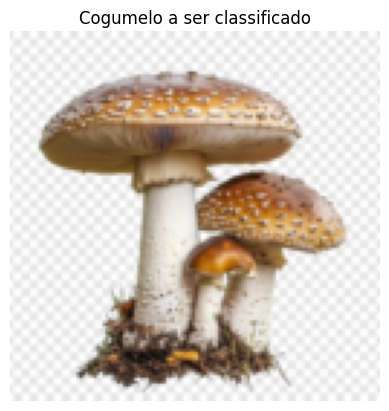

► Palpite Principal: Amanita persicina (Confiança: 19.6%)

Outras opções consideradas (Top 3):
  1º -> Amanita persicina: 19.6%
  2º -> Amanita muscaria: 16.7%
  3º -> Tylopilus felleus: 14.9%


In [14]:
# Caminho do arquivo para teste
target_image_path = "cogumelo.jpg"

# Carregando o modelo salvo
classifier_net.load_state_dict(torch.load(model_filename, map_location=COMPUTE_DEVICE))
classifier_net.eval()

# Leitura e transformação da imagem
pil_img = Image.open(target_image_path).convert("RGB")
tensor_img = image_transforms(pil_img).unsqueeze(0).to(COMPUTE_DEVICE)

# Revertendo a normalização para plotar a imagem corretamente
plot_img = tensor_img.squeeze(0).cpu().numpy()
plot_img = (plot_img * 0.5) + 0.5
plot_img = np.transpose(plot_img, (1, 2, 0))
plot_img = np.clip(plot_img, 0, 1)

plt.imshow(plot_img)
plt.axis('off')
plt.title('Cogumelo a ser classificado')
plt.show()

# Executando a predição
with torch.no_grad():
    raw_scores = classifier_net(tensor_img)
    softmax_probs = torch.softmax(raw_scores, dim=1)[0]

all_class_names = complete_data.classes

# Extraindo o Top 3
highest_probs, highest_indices = torch.topk(softmax_probs, 3)

print(f"► Palpite Principal: {all_class_names[highest_indices[0]]} (Confiança: {highest_probs[0]*100:.1f}%)\n")
print("Outras opções consideradas (Top 3):")

for rank in range(3):
    c_index = highest_indices[rank].item()
    c_prob = highest_probs[rank].item() * 100
    print(f"  {rank+1}º -> {all_class_names[c_index]}: {c_prob:.1f}%")